# Main Fig 6 — Precision-Recall Curves

**Data**: collected prediction parquets (phase0_v3)  
**Tasks (main)**: 2 — apnea detection, BMI  
**Head**: Transformer  
**Layout**: 1 row × 2 cols (`FULL_W` wide, single-column in paper)  

Two tasks chosen to contrast the two principal PR-curve regimes:  
- **(a) apnea_binary** — large AP gain (0.755→0.865, Δ=0.110);  
  gains distributed across full recall range; plateau near 120 min  
- **(b) bmi_binary** — near-flat (0.576→0.615, Δ=0.039);  
  context-insensitive — curves nearly overlap  

Sleep efficiency shows the same large-gain pattern as apnea → inline supp ref.  
Sex, sleep efficiency, OSA, depression → `sfig_pr_curves.pdf`.


In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", fontfamily="serif")

In [4]:
HEAD   = "transformer"
SPLIT  = "test"
SHOW_CONTEXTS = ["30s", "40m", "120m", "240m"]

# ── Main figure: 2 tasks showing contrasting PR-curve regimes ────────────────
# (a) apnea_binary:  large AP gain (0.755→0.865), full-recall-range improvement
# (b) bmi_binary:    near-flat (0.576→0.615) — context-insensitive null case
TASKS  = ["apnea_binary", "bmi_binary"]

pqs = {t: load_parquets("phase0_v3", t, HEAD, SPLIT) for t in TASKS}
print({t: list(v.keys()) for t, v in pqs.items()})


{'apnea_binary': ['30s', '10m', '40m', '80m', '120m', '240m'], 'bmi_binary': ['30s', '10m', '40m', '80m', '120m', '240m']}


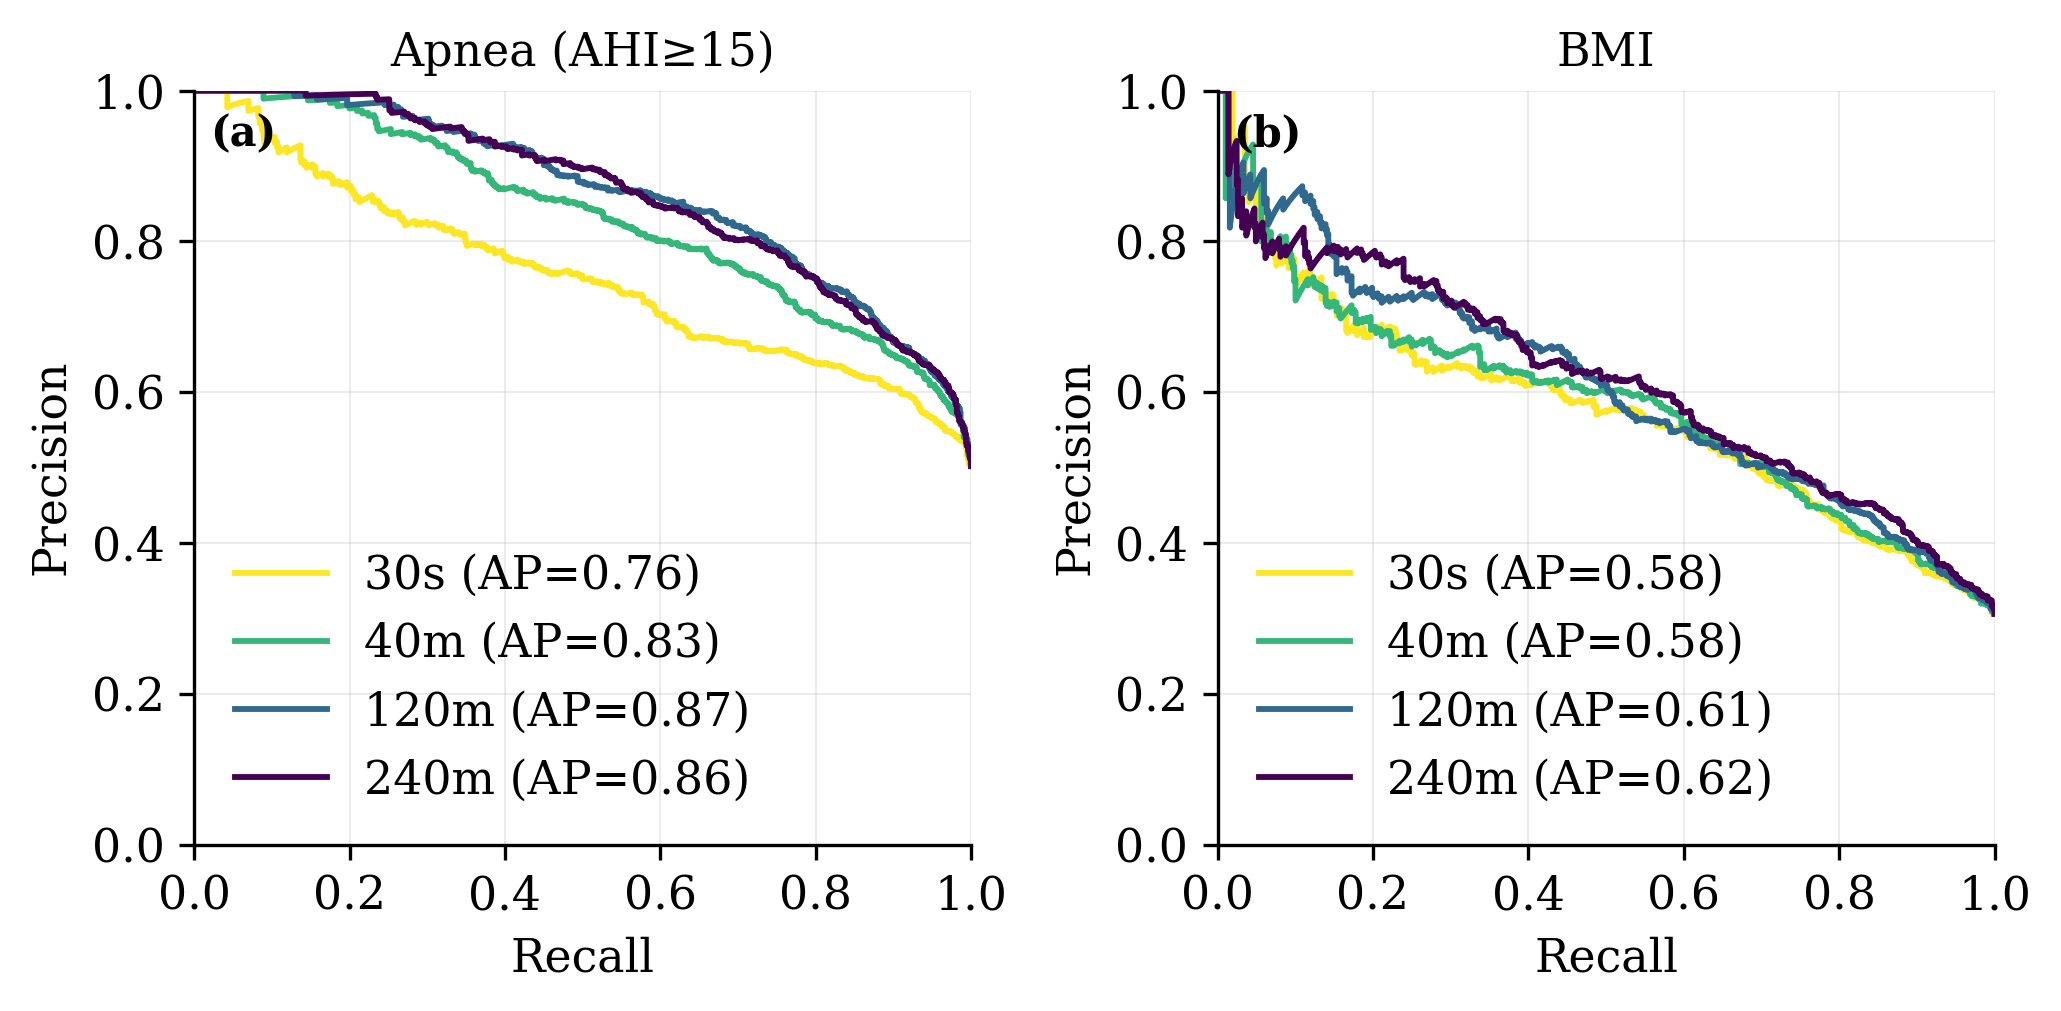

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(FULL_W, 3.5))

for i, (ax, task) in enumerate(zip(axes, TASKS)):
    panels.pr_curves_panel(ax, pqs[task], contexts=SHOW_CONTEXTS)
    ax.set_title(TASK_LABEL[task], fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")

fig.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()


In [8]:
# ── Run when figure looks good ──────────────────────────────────
save_figure(fig, FINAL_OUT, "main_fig6_pr_curves")
import shutil
shutil.copy(FINAL_OUT / "main_fig6_pr_curves.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "main_fig6_pr_curves.pdf")
print("Saved + copied → npj_digital_medicine_submission/main_fig6_pr_curves.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/main_fig6_pr_curves.pdf
Saved + copied → npj_digital_medicine_submission/main_fig6_pr_curves.pdf


## ── SUPPLEMENTARY VERSION ─────────────────────────────────────────────────────

**Target:** `sfig_pr_curves.pdf`  
**→ also copy to:** `npj_digital_medicine_submission/sfig_pr_curves.pdf`  

PR curves for remaining binary tasks not shown in the main figure:  
- **(a) sleep_efficiency_binary** — large gain (0.776→0.874), same pattern as apnea  
- **(b) sex_binary** — large gain (0.838→0.918), high baseline  
- **(c) osa_binary_apples_postqc** — near-ceiling (0.963→0.977), tiny gain  
- **(d) depression_extreme_binary** — unusual: AP *decreases* with context (0.270→0.240)  

> Uncomment all lines in the cell below and run to regenerate.

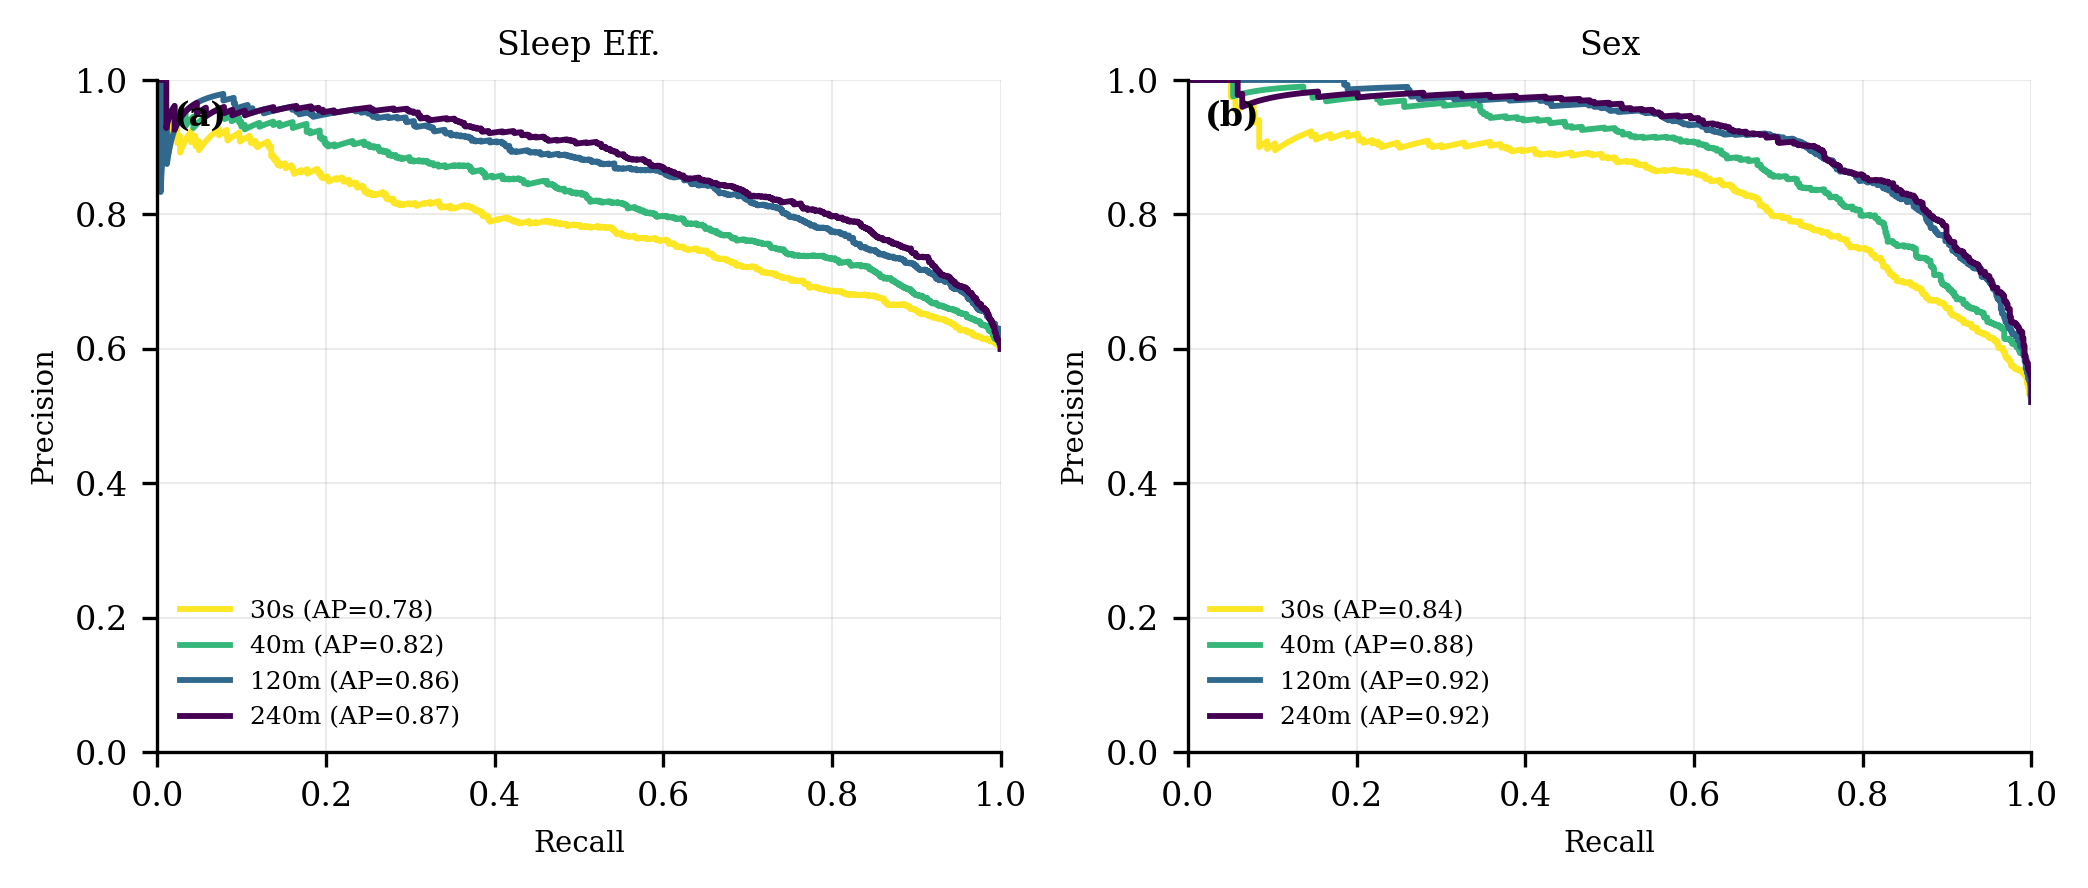

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SUPPLEMENTARY  sfig_pr_curves — PR curves, remaining binary tasks
# Target: sfig_pr_curves.pdf  (copy to npj_digital_medicine_submission/ when done)
# To regenerate: uncomment ALL lines below, then run this cell.
# ══════════════════════════════════════════════════════════════════════════════

_SUPP_PR_TASKS = [
    "sleep_efficiency_binary",    # same large-gain pattern as apnea
    "sex_binary",                 # large gain, high baseline
    # "osa_binary_apples_postqc",   # near-ceiling across all contexts
    # "depression_extreme_binary",  # unusual: AP decreases with context
]
_SUPP_NROWS = 1
_SUPP_NCOLS = 2

_supp_pqs = {t: load_parquets('phase0_v3', t, HEAD, SPLIT)
             for t in _SUPP_PR_TASKS}

fig_supp, _axes = plt.subplots(_SUPP_NROWS, _SUPP_NCOLS,
                               figsize=(FULL_W, _SUPP_NROWS * 3))
_axes_flat = _axes.flatten()
for _i, (_ax, _task) in enumerate(zip(_axes_flat, _SUPP_PR_TASKS)):
    panels.pr_curves_panel(_ax, _supp_pqs[_task], contexts=SHOW_CONTEXTS)
    _ax.set_title(TASK_LABEL[_task], fontsize=FONT_TITLE)
    add_panel_label(_ax, f'({chr(97+_i)})')
for _ax in _axes_flat[len(_SUPP_PR_TASKS):]:
    _ax.set_visible(False)
fig_supp.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()


In [11]:
# Save and copy to npj_digital_medicine_submission
save_figure(fig_supp, FINAL_OUT, 'sfig_pr_curves')
import shutil
_submission = WORKSPACE_ROOT / 'npj_digital_medicine_submission'
shutil.copy(FINAL_OUT / 'sfig_pr_curves.pdf',
            _submission / 'sfig_pr_curves.pdf')
print('Saved + copied → npj_digital_medicine_submission/sfig_pr_curves.pdf')


  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig_pr_curves.pdf
Saved + copied → TBME_submission/sfig_pr_curves.pdf
